In [430]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [431]:
data = pd.read_csv('../M1_final.csv')

In [432]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [433]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

# data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)


### Temporal lag feature

In [434]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

## Stratified train test split

In [ ]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
['is_delayed']
for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Transformers

In [436]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

In [437]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [ ]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition'])
], remainder='passthrough')

## Create Initial Pipeline

In [439]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

# Create initial LightGBM model
lightgbm_model = LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    verbose=-1  # Suppress warnings
)

# Create pipeline
pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('LightGBM', lightgbm_model)
])

print("✓ Initial pipeline created")
print("\nPipeline steps:")
for step_name, step in pipe.steps:
    print(f"  {step_name}: {step.__class__.__name__}")

✓ Initial pipeline created

Pipeline steps:
  Preprocessor: ColumnTransformer
  LightGBM: LGBMClassifier


## Optuna Hyperparameter Optimization

Finding the best hyperparameters for LightGBM with wind interaction feature:

In [440]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# Suppress Optuna's default logging to get clean progress bar
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Define hyperparameter search space for LightGBM
    params = {
        'LightGBM__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'LightGBM__max_depth': trial.suggest_int('max_depth', 3, 10),
        'LightGBM__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'LightGBM__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'LightGBM__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'LightGBM__min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
        'LightGBM__reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'LightGBM__reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
        'LightGBM__num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'LightGBM__min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'LightGBM__verbose': -1,  # Suppress LightGBM output
    }
    
    # Set parameters to the pipeline
    pipe.set_params(**params)
    
    # Perform cross-validation
    # Using accuracy as the metric
    # n_jobs=1 to ensure proper progress display
    cv_scores = cross_val_score(
        pipe, 
        x_train, 
        y_train, 
        cv=5, 
        scoring='accuracy',
        n_jobs=1  # Single job to avoid multiprocessing hiding progress
    )
    
    # Return mean accuracy
    return cv_scores.mean()

In [441]:
# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='LightGBM_WeatherOrder_Tuning',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*60)
print("Optimization Complete!")
print("="*60)

Best trial: 48. Best value: 0.923906: 100%|██████████| 50/50 [01:22<00:00,  1.65s/it]


Optimization Complete!


In [442]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f} ({100 * study.best_trial.value:.2f}%)")
print(f"  Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial:
  Value (Accuracy): 0.9239 (92.39%)
  Number: 48

Best Hyperparameters:
  n_estimators: 466
  max_depth: 9
  learning_rate: 0.13916976403144402
  subsample: 0.9615280601460168
  colsample_bytree: 0.9237784551424427
  min_child_weight: 0.002010103803805137
  reg_alpha: 0.7882540290142857
  reg_lambda: 0.5651679477603272
  num_leaves: 68
  min_child_samples: 96


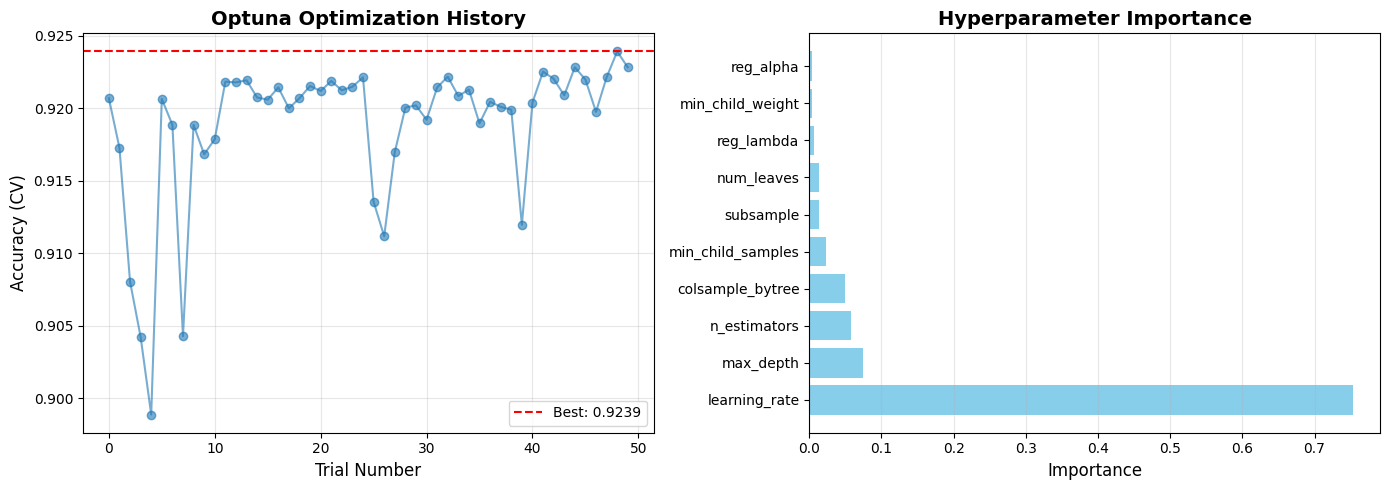


✓ Completed 50 trials
✓ Best trial achieved 92.39% accuracy


In [443]:
# Visualize optimization history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-', alpha=0.6)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial Number', fontsize=12)
axes[0].set_ylabel('Accuracy (CV)', fontsize=12)
axes[0].set_title('Optuna Optimization History', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Parameter importance
try:
    param_importance = optuna.importance.get_param_importances(study)
    params = list(param_importance.keys())
    importances = list(param_importance.values())
    
    axes[1].barh(params, importances, color='skyblue')
    axes[1].set_xlabel('Importance', fontsize=12)
    axes[1].set_title('Hyperparameter Importance', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='x')
except:
    axes[1].text(0.5, 0.5, 'Not enough trials\nfor importance analysis', 
                 ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Completed {len(study.trials)} trials")
print(f"✓ Best trial achieved {100 * study.best_value:.2f}% accuracy")

In [444]:
# Extract best parameters from the study
best_params = study.best_params
print("Best parameters extracted from study:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Save the best parameters and model for future use
import pickle
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save best parameters
params_filename = f'../saved_models/LightGBM_BestParams_2_{timestamp}.pkl'
with open(params_filename, 'wb') as f:
    pickle.dump(best_params, f)
print(f"\n✓ Best parameters saved to: {params_filename}")

# Save the trained model
model_filename = f'../saved_models/LightGBM_model_2_{timestamp}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(pipe, f)
print(f"✓ Trained model saved to: {model_filename}")

Best parameters extracted from study:
  n_estimators: 466
  max_depth: 9
  learning_rate: 0.13916976403144402
  subsample: 0.9615280601460168
  colsample_bytree: 0.9237784551424427
  min_child_weight: 0.002010103803805137
  reg_alpha: 0.7882540290142857
  reg_lambda: 0.5651679477603272
  num_leaves: 68
  min_child_samples: 96

✓ Best parameters saved to: ../saved_models/LightGBM_BestParams_2_20251029_200956.pkl
✓ Trained model saved to: ../saved_models/LightGBM_model_2_20251029_200956.pkl


In [445]:
# Train final model with best parameters
best_params_with_prefix = {f'LightGBM__{key}': value for key, value in study.best_params.items()}
best_params_with_prefix['LightGBM__verbose'] = -1  # Keep suppressed

pipe.set_params(**best_params_with_prefix)

# Fit the model
print("Training final model with best parameters...")
pipe.fit(x_train, y_train)
print("✓ Model training completed!")

print("\nFinal pipeline steps:")
for step_name, step in pipe.steps:
    print(f"  {step_name}: {step.__class__.__name__}")

Training final model with best parameters...
✓ Model training completed!

Final pipeline steps:
  Preprocessor: ColumnTransformer
  LightGBM: LGBMClassifier
✓ Model training completed!

Final pipeline steps:
  Preprocessor: ColumnTransformer
  LightGBM: LGBMClassifier


## Train the Model

In [446]:
# Train the pipeline
print("Training LightGBM model with optimized hyperparameters...")
pipe.fit(x_train, y_train)
print("✓ Model training completed!")

Training LightGBM model with optimized hyperparameters...
✓ Model training completed!
✓ Model training completed!


## Evaluate Model Performance

In [447]:
# Make predictions and evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*60)
print("Test Set Performance")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({100 * accuracy:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*60)

Test Set Performance
Accuracy:  0.9470 (94.70%)
Precision: 0.8117
Recall:    0.8076
F1 Score:  0.8096


In [448]:
# Classification Report
from sklearn.metrics import classification_report

print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

Classification Report:
              precision    recall  f1-score   support

 Not Delayed       0.97      0.97      0.97      7440
     Delayed       0.81      0.81      0.81      1206

    accuracy                           0.95      8646
   macro avg       0.89      0.89      0.89      8646
weighted avg       0.95      0.95      0.95      8646



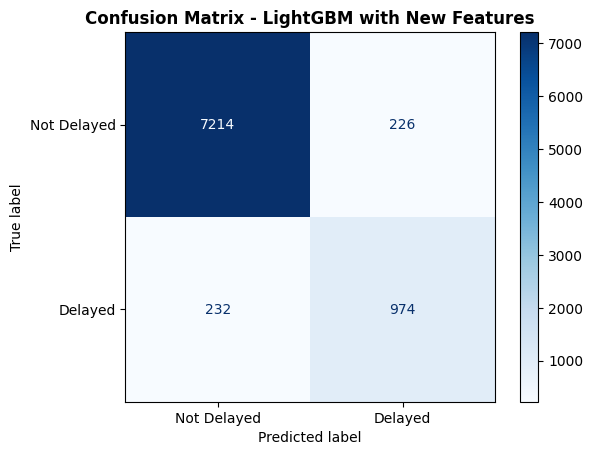


Specificity (True Negative Rate): 0.9696 (96.96%)
Sensitivity (True Positive Rate/Recall): 0.8076 (80.76%)


In [449]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - LightGBM with New Features', fontweight='bold')
plt.show()

# Calculate Specificity and Sensitivity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f'\nSpecificity (True Negative Rate): {specificity:.4f} ({100 * specificity:.2f}%)')
print(f'Sensitivity (True Positive Rate/Recall): {sensitivity:.4f} ({100 * sensitivity:.2f}%)')

ROC AUC Score: 0.9831 (98.31%)


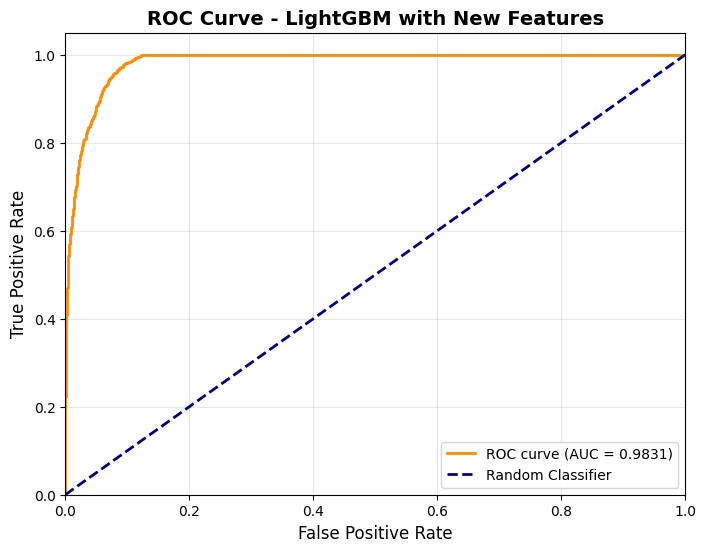

In [450]:
# ROC AUC Score and Curve
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {roc_auc:.4f} ({100 * roc_auc:.2f}%)')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - LightGBM with New Features', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [451]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28818 entries, 0 to 28819
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28818 non-null  int64  
 1   DAY_OF_MONTH       28818 non-null  int64  
 2   DAY_OF_WEEK        28818 non-null  int64  
 3   OP_UNIQUE_CARRIER  28818 non-null  object 
 4   DEST               28818 non-null  object 
 5   CRS_ELAPSED_TIME   28818 non-null  int64  
 6   DISTANCE           28818 non-null  int64  
 7   CRS_DEP_M          28818 non-null  int64  
 8   CRS_ARR_M          28818 non-null  int64  
 9   Temperature        28818 non-null  int64  
 10  Dew Point          28818 non-null  object 
 11  Humidity           28818 non-null  int64  
 12  Wind               28818 non-null  object 
 13  Wind Speed         28818 non-null  int64  
 14  Wind Gust          28818 non-null  int64  
 15  Pressure           28818 non-null  float64
 16  Condition          28818 no